# Dự án Churn Prediction - Giai đoạn 1: EDA & Làm sạch dữ liệu
**Người thực hiện:** AIE Data
**Mục tiêu:** Phân tích các yếu tố dẫn đến rời bỏ dịch vụ và chuẩn bị dữ liệu sạch cho Model.

# 1. TÁCH BỘ DỮ LIỆU RAW THÀNH TRAIN VÀ TEST

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# 1. Đường dẫn (Sử dụng r"" để tránh lỗi gạch chéo)
path = r"D:\AIO Tài liệu\Warm up 04\Project 01\Churn-Prediction\data\raw\ecommerce_churn.xlsx"

# 2. Đọc Sheet thứ 2 (sheet_name=1)
# Nếu máy báo lỗi "ImportError: Missing optional dependency 'openpyxl'", 
# bạn hãy vào Terminal gõ: pip install openpyxl
df = pd.read_excel(path, sheet_name="E Comm")

# 3. Làm sạch tên cột (đề phòng khoảng trắng thừa)
df.columns = df.columns.str.strip()

# Kiểm tra thử xem đã thấy cột Churn chưa
print("Danh sách cột đã tìm thấy:", df.columns.tolist())
print(f"Tổng số dòng dữ liệu: {len(df)}")

# 4. Nếu đã thấy cột 'Churn', tiến hành chia dữ liệu
if 'Churn' in df.columns:
    train_df, test_df = train_test_split(
        df, 
        test_size=0.2, 
        random_state=42, 
        stratify=df['Churn']
    )
    
    # 5. Lưu vào thư mục processed
    os.makedirs('../data/processed', exist_ok=True)
    train_df.to_csv('../data/processed/train.csv', index=False)
    test_df.to_csv('../data/processed/test.csv', index=False)
    print("--- THÀNH CÔNG: Đã chia Train/Test và lưu file! ---")
else:
    print("Vẫn chưa tìm thấy cột 'Churn'. Hãy kiểm tra lại tên Sheet!")

: 

# 2. KHÁM PHÁ VÀ XỬ LÝ DỮ LIỆU TẠO CLEANED DATA
# **Kiểm tra missing value**

In [15]:
import pandas as pd
# Đọc lại tập train đã lưu
train_df = pd.read_csv('../data/processed/train.csv')

# Kiểm tra các cột có giá trị thiếu
missing_data = train_df.isnull().sum()
print("Các cột bị thiếu dữ liệu:\n", missing_data[missing_data > 0])

Các cột bị thiếu dữ liệu:
 Tenure                         213
WarehouseToHome                206
HourSpendOnApp                 197
OrderAmountHikeFromlastYear    208
CouponUsed                     208
OrderCount                     212
DaySinceLastOrder              247
dtype: int64


**Nhận xét**
Tenure (Thâm niên): Thiếu 213. Đây là biến cực kỳ quan trọng. Khách hàng mới thường dễ bỏ đi hơn khách hàng cũ.
DaySinceLastOrder (Ngày từ đơn hàng cuối): Thiếu 247 (nhiều nhất). Biến này đo lường độ "nóng" của khách hàng.
WarehouseToHome (Kho đến nhà): Thiếu 206. Khoảng cách địa lý ảnh hưởng đến tốc độ giao hàng.
=> Vá lỗ hổng bằng trung vị

# **Vá lỗi dữ liệu bằng trung vị**

In [16]:
# 1. Danh sách các cột cần vá (Numerical columns)
cols_to_fix = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
    'OrderAmountHikeFromlastYear', 'CouponUsed', 
    'OrderCount', 'DaySinceLastOrder'
]

# 2. Vá lỗi bằng Median (Trung vị)
for col in cols_to_fix:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)

# 3. Kiểm tra lại xem còn lỗ hổng nào không
print("Số lượng giá trị thiếu sau khi vá:")
print(train_df.isnull().sum().sum())

Số lượng giá trị thiếu sau khi vá:
0


# **Kiểm tra tỷ lệ rời bỏ Churn**

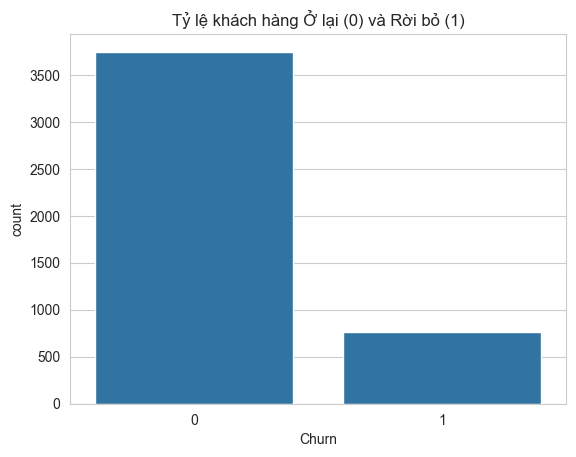

Churn
0    83.170515
1    16.829485
Name: proportion, dtype: float64


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ biểu đồ đếm số lượng
sns.countplot(x='Churn', data=train_df)
plt.title('Tỷ lệ khách hàng Ở lại (0) và Rời bỏ (1)')
plt.show()

# Xem tỷ lệ phần trăm cụ thể
print(train_df['Churn'].value_counts(normalize=True) * 100)

**Nhận xét** Dữ liệu hợp lý nhưng bị imbalance, nếu đưa vào huấn luyện chỉ dự đoán 0 thì cũng đạt độ chính xác 83%.

# **Kiểm tra trùng lặp và điểm dị biệt (outliers)**

In [18]:
# Kiểm tra số lượng dòng trùng lặp
duplicate_count = train_df.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {duplicate_count}")

# Nếu có, chúng ta sẽ xóa bỏ và chỉ giữ lại dòng đầu tiên
if duplicate_count > 0:
    train_df = train_df.drop_duplicates()
    print("Đã xóa các dòng trùng lặp!")

Số lượng dòng trùng lặp: 0


In [19]:
# KIỂM TRA OUTLIERS
# 1. Tìm tất cả các cột số
num_features = train_df.select_dtypes(include=['int64', 'float64']).columns

# 2. Tính toán tỷ lệ Outlier ở mỗi cột
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

for col in num_features:
    outlier_count = count_outliers(train_df, col)
    if outlier_count > 0:
        percentage = (outlier_count / len(train_df)) * 100
        print(f"Cột {col}: có {outlier_count} outliers ({percentage:.2f}%)")

Cột Churn: có 758 outliers (16.83%)
Cột Tenure: có 2 outliers (0.04%)
Cột WarehouseToHome: có 1 outliers (0.02%)
Cột HourSpendOnApp: có 4 outliers (0.09%)
Cột NumberOfDeviceRegistered: có 327 outliers (7.26%)
Cột NumberOfAddress: có 3 outliers (0.07%)
Cột OrderAmountHikeFromlastYear: có 28 outliers (0.62%)
Cột CouponUsed: có 502 outliers (11.15%)
Cột OrderCount: có 545 outliers (12.10%)
Cột DaySinceLastOrder: có 42 outliers (0.93%)
Cột CashbackAmount: có 343 outliers (7.62%)


# **Vẽ đồ thị outliers các cột**#

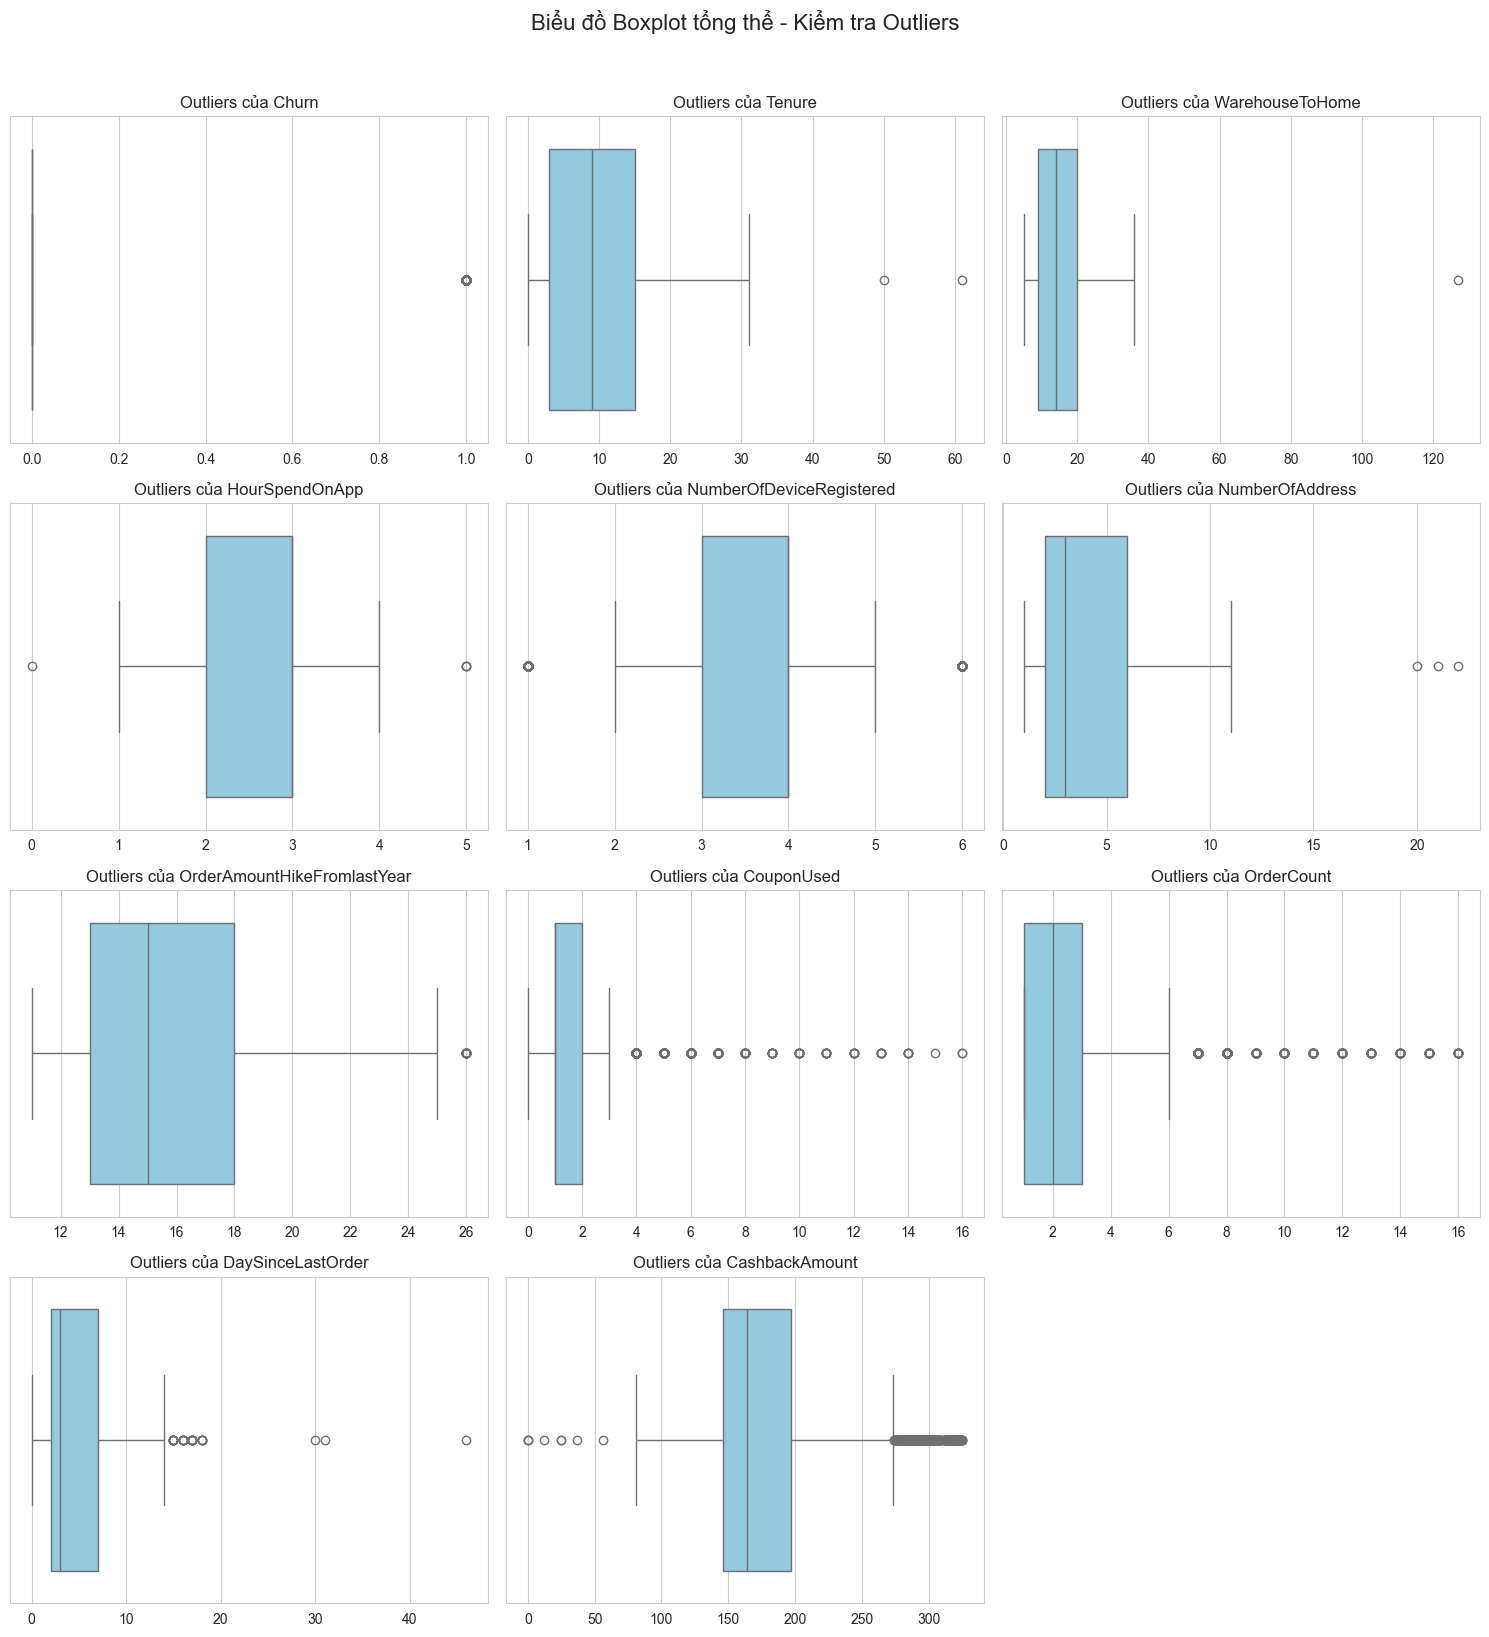

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Danh sách các cột bạn muốn vẽ (dựa trên danh sách bạn đã liệt kê)
num_features = [
    'Churn', 'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
    'NumberOfDeviceRegistered', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 
    'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'
]

# 2. Tính toán số hàng và số cột cho khung hình (Grid)
# Ví dụ: 11 cột thì chia thành 4 hàng, mỗi hàng 3 biểu đồ
n_cols = 3
n_rows = math.ceil(len(num_features) / n_cols)

# 3. Khởi tạo khung hình
plt.figure(figsize=(15, n_rows * 4))
plt.suptitle('Biểu đồ Boxplot tổng thể - Kiểm tra Outliers', fontsize=16, y=1.02)

for i, col in enumerate(num_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=train_df[col], color='skyblue')
    plt.title(f'Outliers của {col}')
    plt.xlabel('') # Ẩn tên cột ở trục X cho đỡ rối

# 4. Tự động căn chỉnh để các biểu đồ không đè lên nhau
plt.tight_layout()
plt.show()

# **Dùng phương pháp IQR để xử lý outlier và endcoding các dữ liệu chữ thành dữ liệu 0 và 1**

In [21]:
import pandas as pd

# A. ĐỊNH NGHĨA LẠI HÀM (Để máy nhớ lại cách xử lý Outlier)
def handle_outliers(df, column):
    # Sử dụng phương pháp IQR (Interquartile Range)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping: Thay thế giá trị ngoài biên bằng giá trị biên
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# B. THỰC HIỆN XỬ LÝ CHIẾN THUẬT [cite: 642]
# Chỉ cắt những cột có Outlier cực thấp (<1%) để tránh mất tín hiệu quan trọng 
cols_to_cap = ['WarehouseToHome', 'Tenure', 'DaySinceLastOrder']

for col in cols_to_cap:
    train_df = handle_outliers(train_df, col)

# C. CHUẨN HÓA LẦN CUỐI (Encoding) [cite: 114, 503, 642]
cat_cols = train_df.select_dtypes(include=['object']).columns
train_final = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)

# D. LƯU FILE
import os
os.makedirs('../data/processed', exist_ok=True)
train_final.to_csv('../data/processed/cleaned_data.csv', index=False)

print("--- CHÚC MỪNG: DỮ LIỆU ĐÃ SẠCH VÀ CHUẨN CHIẾN THUẬT! ---")
print(f"Số lượng cột cuối cùng: {train_final.shape[1]}")

--- CHÚC MỪNG: DỮ LIỆU ĐÃ SẠCH VÀ CHUẨN CHIẾN THUẬT! ---
Số lượng cột cuối cùng: 31


C:\Users\tpbin\AppData\Local\Temp\ipykernel_21004\115974096.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=['object']).columns


# **Tính ma trận tương quan**

Độ tương quan với cột Churn:
Churn                                    1.000000
Complain                                 0.247916
MaritalStatus_Single                     0.178380
PreferedOrderCat_Mobile Phone            0.163956
NumberOfDeviceRegistered                 0.115361
SatisfactionScore                        0.111479
PreferedOrderCat_Mobile                  0.103470
CityTier                                 0.096892
PreferredPaymentMode_COD                 0.088613
PreferredLoginDevice_Phone               0.075612
WarehouseToHome                          0.070461
PreferredPaymentMode_E wallet            0.063623
NumberOfAddress                          0.042664
Gender_Male                              0.032610
HourSpendOnApp                           0.016654
PreferredPaymentMode_UPI                 0.004440
CouponUsed                              -0.000833
PreferredPaymentMode_Cash on Delivery   -0.008856
OrderAmountHikeFromlastYear             -0.009311
CustomerID           

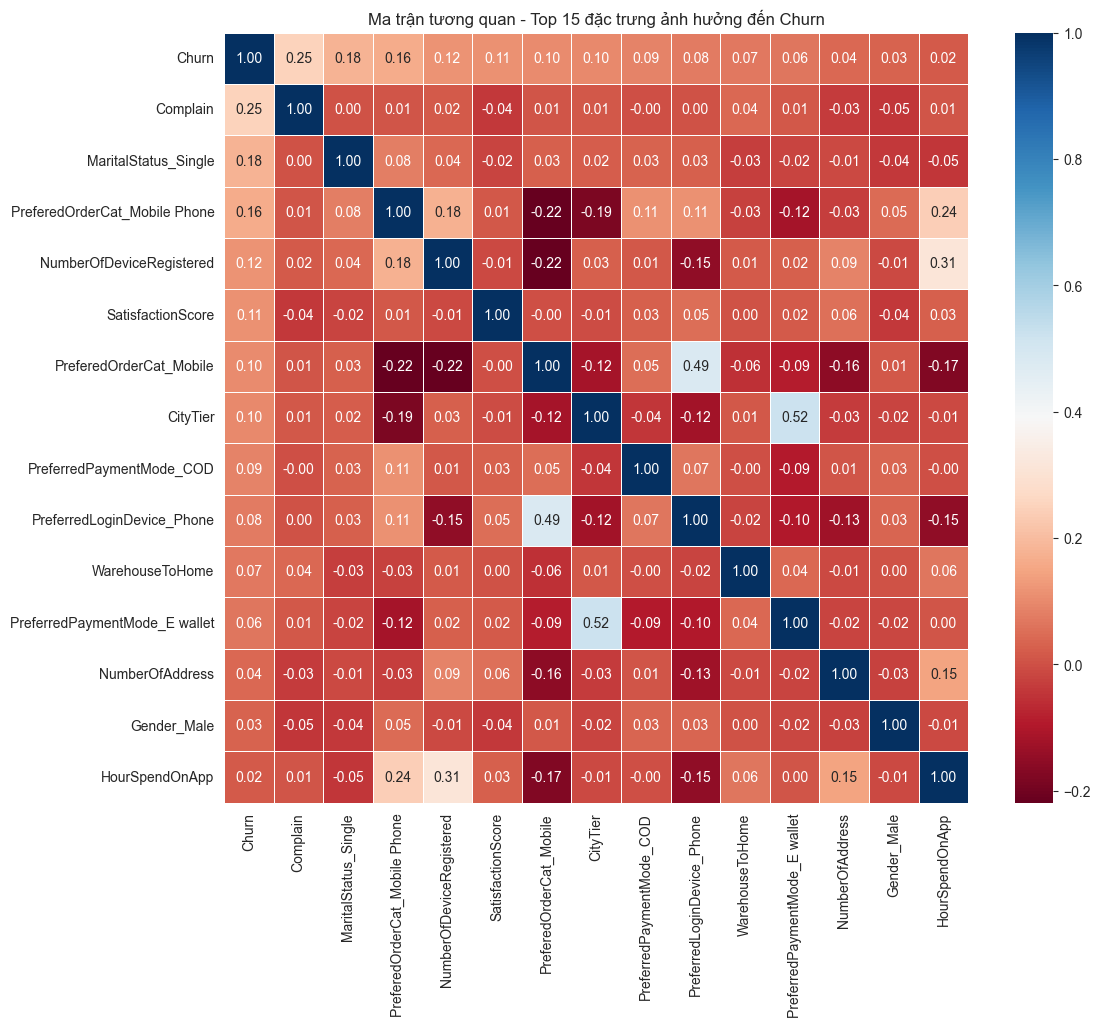

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính ma trận tương quan
# Lưu ý: ma trận này chỉ tính được trên dữ liệu số (đã encode) 
corr_matrix = train_final.corr()

# 2. Xem độ tương quan của các biến đối với biến mục tiêu Churn
# Sắp xếp giảm dần để thấy biến nào ảnh hưởng mạnh nhất
target_corr = corr_matrix['Churn'].sort_values(ascending=False)
print("Độ tương quan với cột Churn:")
print(target_corr)

# 3. Vẽ biểu đồ Heatmap cho toàn bộ các đặc trưng
# Chọn top các biến có tương quan cao nhất để biểu đồ không bị quá dày đặc
top_features = target_corr.index[:15] # Lấy top 15 biến tương quan mạnh nhất

plt.figure(figsize=(12, 10))
sns.heatmap(train_final[top_features].corr(), 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu', # Màu đỏ (tương quan dương), Xanh (tương quan âm)
            linewidths=0.5)

plt.title('Ma trận tương quan - Top 15 đặc trưng ảnh hưởng đến Churn')
plt.show()

C:\Users\tpbin\AppData\Local\Temp\ipykernel_21004\2290628513.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x=col, hue='Churn', shade=True, palette='magma')
C:\Users\tpbin\AppData\Local\Temp\ipykernel_21004\2290628513.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x=col, hue='Churn', shade=True, palette='magma')
C:\Users\tpbin\AppData\Local\Temp\ipykernel_21004\2290628513.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x=col, hue='Churn', shade=True, palette='magma')
C:\Users\tpbin\AppData\Local\Temp\ipykernel_21004\2290628513.py:11: FutureWarning: 

`shade` is now deprecated i

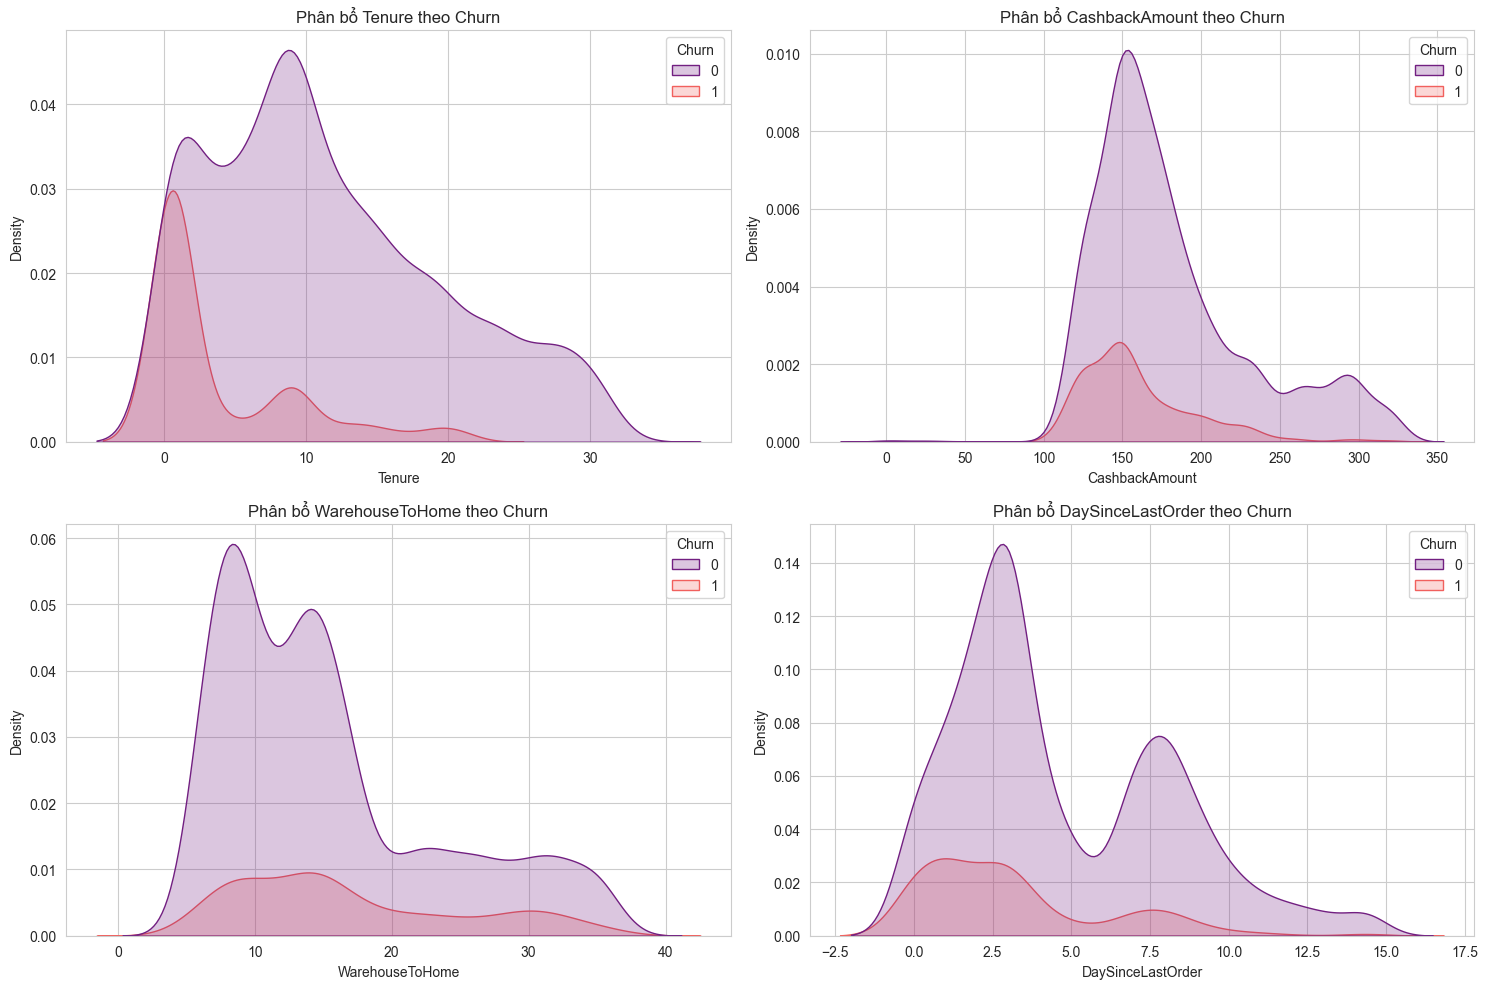

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ecommerce_numerical(df):
    cols = ['Tenure', 'CashbackAmount', 'WarehouseToHome', 'DaySinceLastOrder']
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(cols):
        plt.subplot(2, 2, i+1)
        # Vẽ KDE để xem mật độ nhóm bỏ đi (Churn=1) và ở lại (Churn=0)
        sns.kdeplot(data=df, x=col, hue='Churn', shade=True, palette='magma')
        plt.title(f'Phân bổ {col} theo Churn')
    
    plt.tight_layout()
    plt.show()

plot_ecommerce_numerical(train_final)

Danh sách cột trong data của bạn: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


C:\Users\tpbin\AppData\Local\Temp\ipykernel_21004\2343068361.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='viridis')


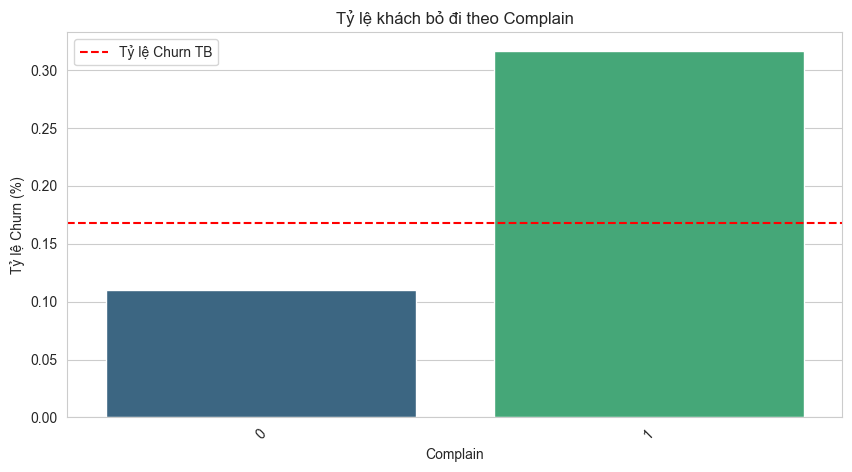

C:\Users\tpbin\AppData\Local\Temp\ipykernel_21004\2343068361.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='viridis')


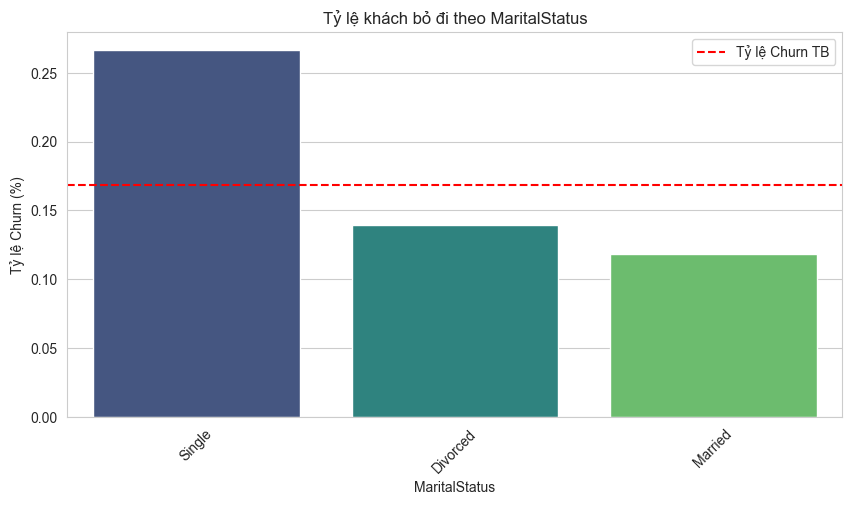

C:\Users\tpbin\AppData\Local\Temp\ipykernel_21004\2343068361.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='viridis')


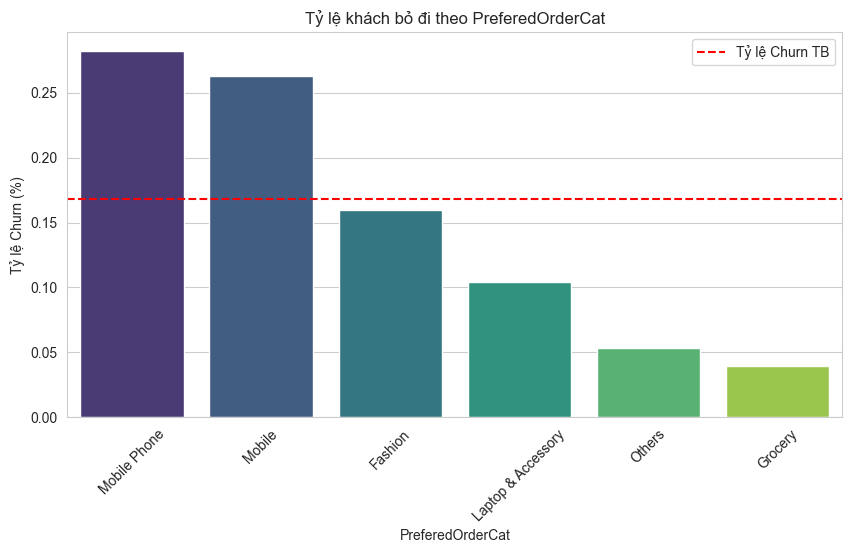

C:\Users\tpbin\AppData\Local\Temp\ipykernel_21004\2343068361.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='viridis')


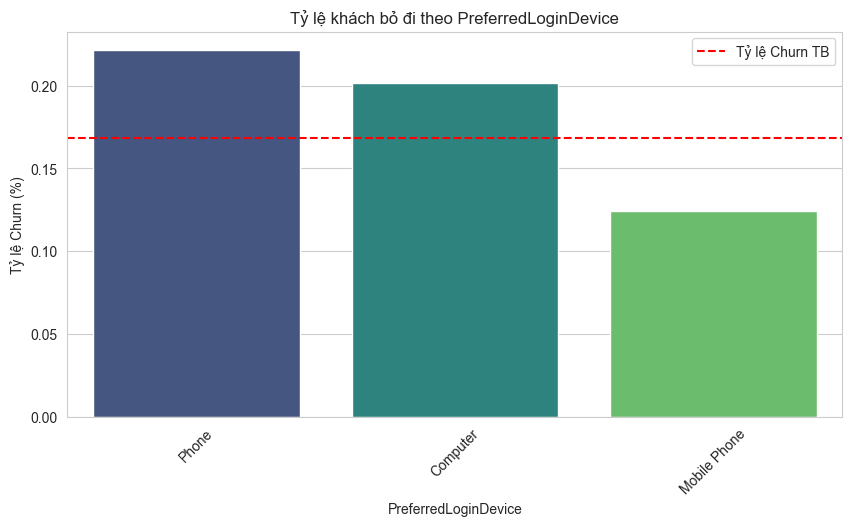

C:\Users\tpbin\AppData\Local\Temp\ipykernel_21004\2343068361.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='viridis')


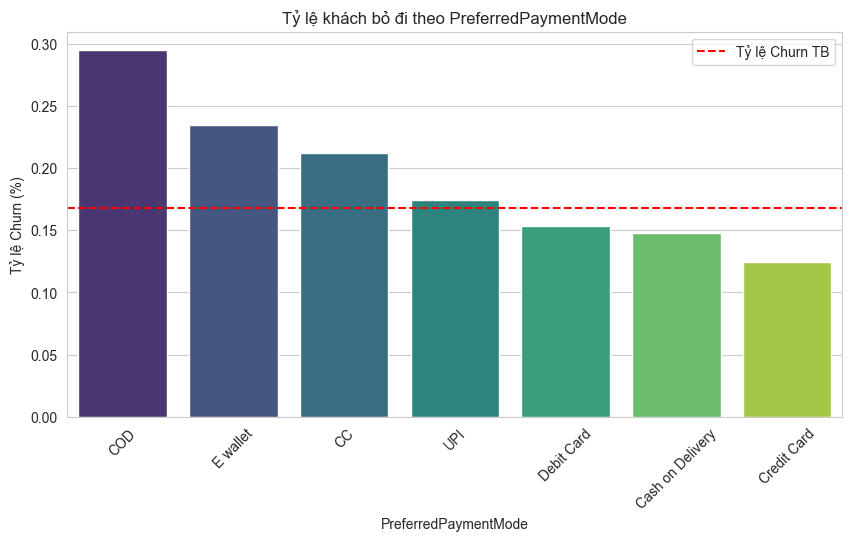

In [27]:
# Kiểm tra danh sách cột thực tế để tránh lỗi chính tả
print("Danh sách cột trong data của bạn:", train_df.columns.tolist())

# Danh sách các biến định danh (Categorical) - Chú ý chính tả Prefe(r)ed
cat_cols = ['Complain', 'MaritalStatus', 'PreferedOrderCat', 'PreferredLoginDevice', 'PreferredPaymentMode']

# Chỉ lấy những cột thực sự tồn tại trong DataFrame
existing_cat_cols = [col for col in cat_cols if col in train_df.columns]

def plot_ecommerce_categorical(df, cols):
    for col in existing_cat_cols:
        plt.figure(figsize=(10, 5))
        # Tính tỷ lệ Churn trung bình theo từng nhóm
        churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
        
        sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='viridis')
        plt.axhline(df['Churn'].mean(), color='red', linestyle='--', label='Tỷ lệ Churn TB')
        plt.title(f'Tỷ lệ khách bỏ đi theo {col}')
        plt.ylabel('Tỷ lệ Churn (%)')
        plt.xticks(rotation=45)
        plt.legend()
        plt.show()

plot_ecommerce_categorical(train_df, existing_cat_cols)

**Complain**: Đây là biến có sức mạnh dự báo lớn nhất. Khách hàng có khiếu nại (Complain=1) có tỷ lệ rời bỏ lên đến trên 30%, cao gấp 3 lần so với nhóm không khiếu nại (~11%).=> 
# Hành động: Hệ thống CSKH cần ưu tiên xử lý khiếu nại ngay lập tức để giữ chân khách.
**Tenure**: Biểu đồ mật độ (KDE) cho thấy đỉnh sóng Churn nằm ở nhóm có Tenure từ 0 đến 5 tháng. Sau 10 tháng, tỷ lệ này giảm sâu và đi ngang.
# 6 tháng đầu tiên là giai đoạn "trăng mật" cực kỳ nhạy cảm. Các chương trình khuyến mãi/ưu đãi cần tập trung mạnh vào nhóm khách hàng mới này
**PreferedOrderCat**: Khách hàng mua sắm trong danh mục Mobile Phone có tỷ lệ rời bỏ cao nhất (gần 30%), theo sau là nhóm Phone. Các nhóm như Grocery hay Fashion có độ trung thành cao hơn nhiều.
# Có thể khách tìm mua sản phẩm điện tử với giá thành cao nhằm áp dụng khuyến mãi giảm giá cho người mới, chỉ mua 1 lần, sau khi mua xong thì chuyển sang sàn khác
**MaritalStatus**: Người Độc thân (Single) có tỷ lệ Churn cao nhất (khoảng 25-27%), trong khi người đã kết hôn hoặc ly hôn có xu hướng ổn định hơn (khoảng 12-14%)
# Nhóm Single có xu hướng chạy theo giá và trải nghiệm mới nhanh hơn. Cần các chiến dịch Marketing trẻ trung, linh hoạt cho đối tượng này
